# Cross-measure correlation overview

Principled, extensible version of the ad-hoc joins in `across-measur_ana.ipynb`.

- All measures are loaded from `measures_registry.py` (one loader function + one
  registry entry per measure, tagged with a `category`).
- **To add a new measure**: write a `_load_*` function in `measures_registry.py`
  and add it to `REGISTRY`. Nothing here needs to change.
- Risk-task measures (`category == 'behavioral_risk'`) are **excluded by default**
  — pass `exclude_categories=set()` or `include_categories=[...]` to bring them in.
- Different model versions of the same measure (e.g. magjudge bauer biased vs.
  unbiased) are registered as **separate named entries**, sharing a category but
  with distinct, suffixed column names — so they show up side by side rather than
  silently overwriting each other.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin

from measures_registry import load_all, REGISTRY

sns.set_context('notebook')
plot_folder = '/Users/mrenke/data/ds-dnumrisk/plots_and_ims/correlations_across_measures'

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load measures

Default: behavioral + neural, risk-task measures excluded.

In [2]:
df, col_to_category = load_all()
print(df.shape)
df.head()

(66, 24)


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


,age,group,gender,gamma_magjudge,intercept_magjudge,n1_slope,intercept_magjudge_abs,memory_noise_sd,perceptual_noise_sd,skill_score,...,mean_iq,erfassungsspanne,weber_transformed,r,NPC_dispersion,Dorsal-attention_size,Visual2_size,DANpatch_L_frontal-lateral,DANpatch_L_parietal-lateral,DANpatch_R_parietal-lateral
subject,,,,,,,,,,,,,,,,,,,,,
1,19.0,control,w,4.705314,-0.201185,0.025097,0.201185,0.115213,0.102558,36.0,...,112.5,8,-1.943288,-0.058083,0.001094,70.592925,1.466819,28.938550,48.147020,53.470740
2,17.0,dyscalc,w,3.425356,0.046009,0.048086,0.046009,0.196658,0.122329,6.0,...,97.5,6,-2.121318,0.206071,0.001425,49.514092,23.325820,10.040092,40.493140,45.472610
3,15.0,control,w,2.933502,-0.153413,0.032216,0.153413,0.213540,0.150741,29.0,...,105.0,5,-1.052099,NaN,0.001159,73.638125,7.222400,20.363247,46.913325,58.338623
4,17.0,dyscalc,w,4.930412,-0.136875,0.037974,0.136875,0.105920,0.091129,34.0,...,107.5,6,-1.694361,-0.089840,0.002552,81.994629,8.334771,34.493240,67.235650,55.377275
5,20.0,control,w,3.599923,-0.279398,0.022015,0.279398,0.127888,0.153583,30.0,...,102.5,7,-1.869560,-0.023735,0.001329,NaN,NaN,NaN,NaN,NaN


## Correlation matrix

Demographic columns (`age`, `group`, `gender`) are kept aside — `group` is used
for coloring/splitting, not included in the numeric correlation matrix.

In [3]:
demographic_cols = [c for c, cat in col_to_category.items() if cat == 'demographics']
corr_vars = [c for c in df.columns if c not in demographic_cols]

corr = df[corr_vars].corr(method='spearman')
corr.shape

(21, 21)

## Plain heatmap, variables sorted by category

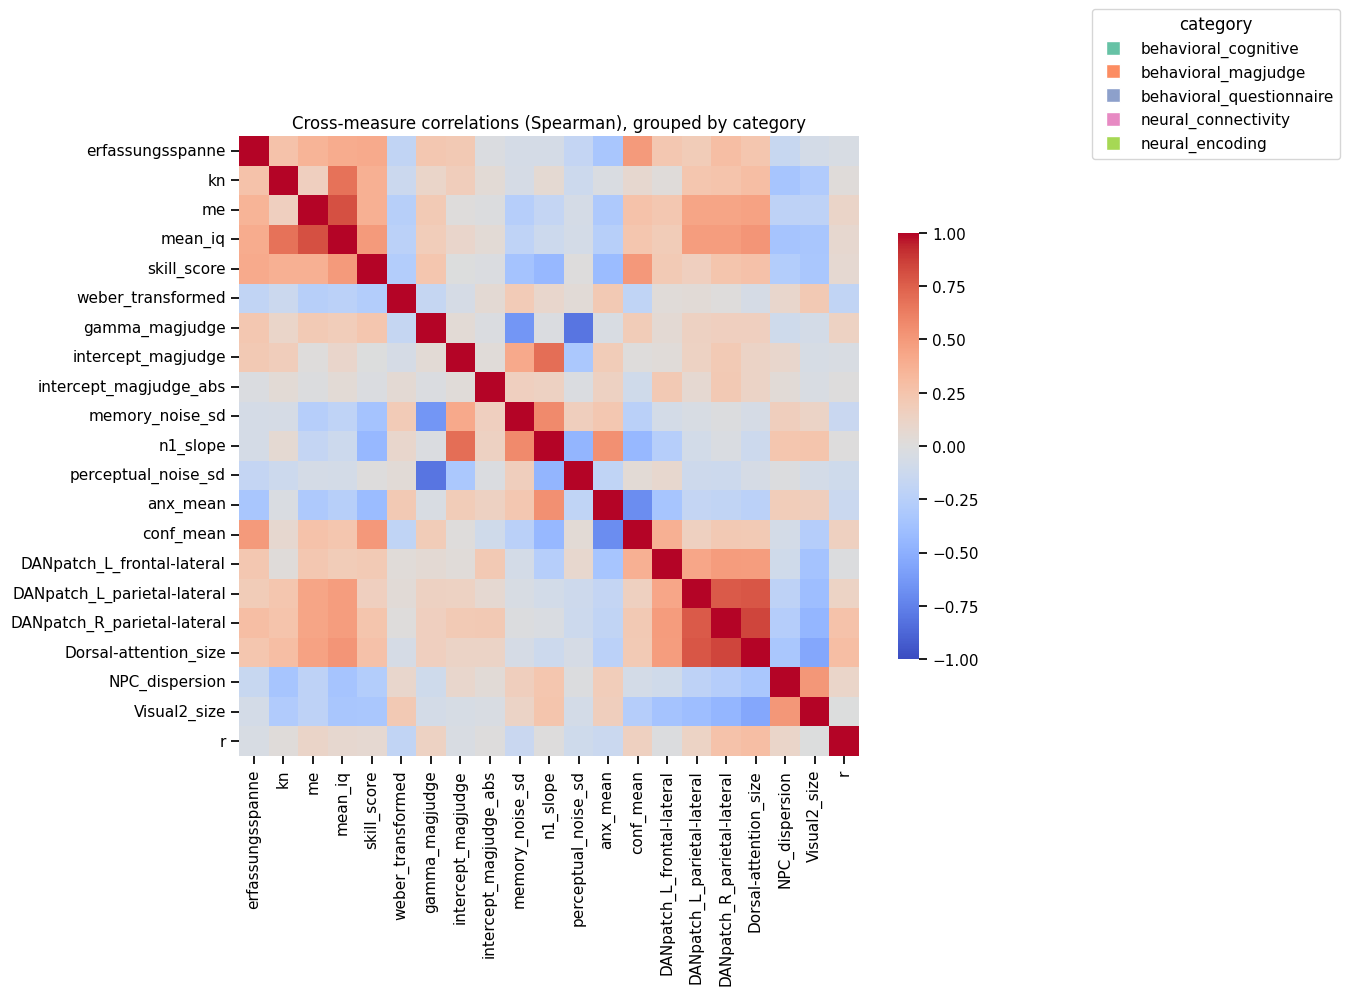

In [4]:
order = sorted(corr_vars, key=lambda c: (col_to_category.get(c, ''), c))
corr_sorted = corr.loc[order, order]

categories = sorted(set(col_to_category[c] for c in order))
palette = dict(zip(categories, sns.color_palette('Set2', len(categories))))
side_colors = pd.Series([palette[col_to_category[c]] for c in order], index=order)

fig, ax = plt.subplots(figsize=(0.4 * len(order) + 2, 0.4 * len(order) + 2))
sns.heatmap(corr_sorted, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.5})
ax.set_title('Cross-measure correlations (Spearman), grouped by category')

handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=palette[cat], markersize=10)
           for cat in categories]
fig.legend(handles, categories, loc='upper left', bbox_to_anchor=(1.05, 1), title='category')
plt.tight_layout()
# plt.savefig(op.join(plot_folder, 'cross_measure_heatmap_by_category.png'), dpi=300, bbox_inches='tight')

## Clustered version (hierarchical clustering, categories as side color bar)

Text(0.5, 1.02, 'Cross-measure correlations (Spearman), clustered by |r|')

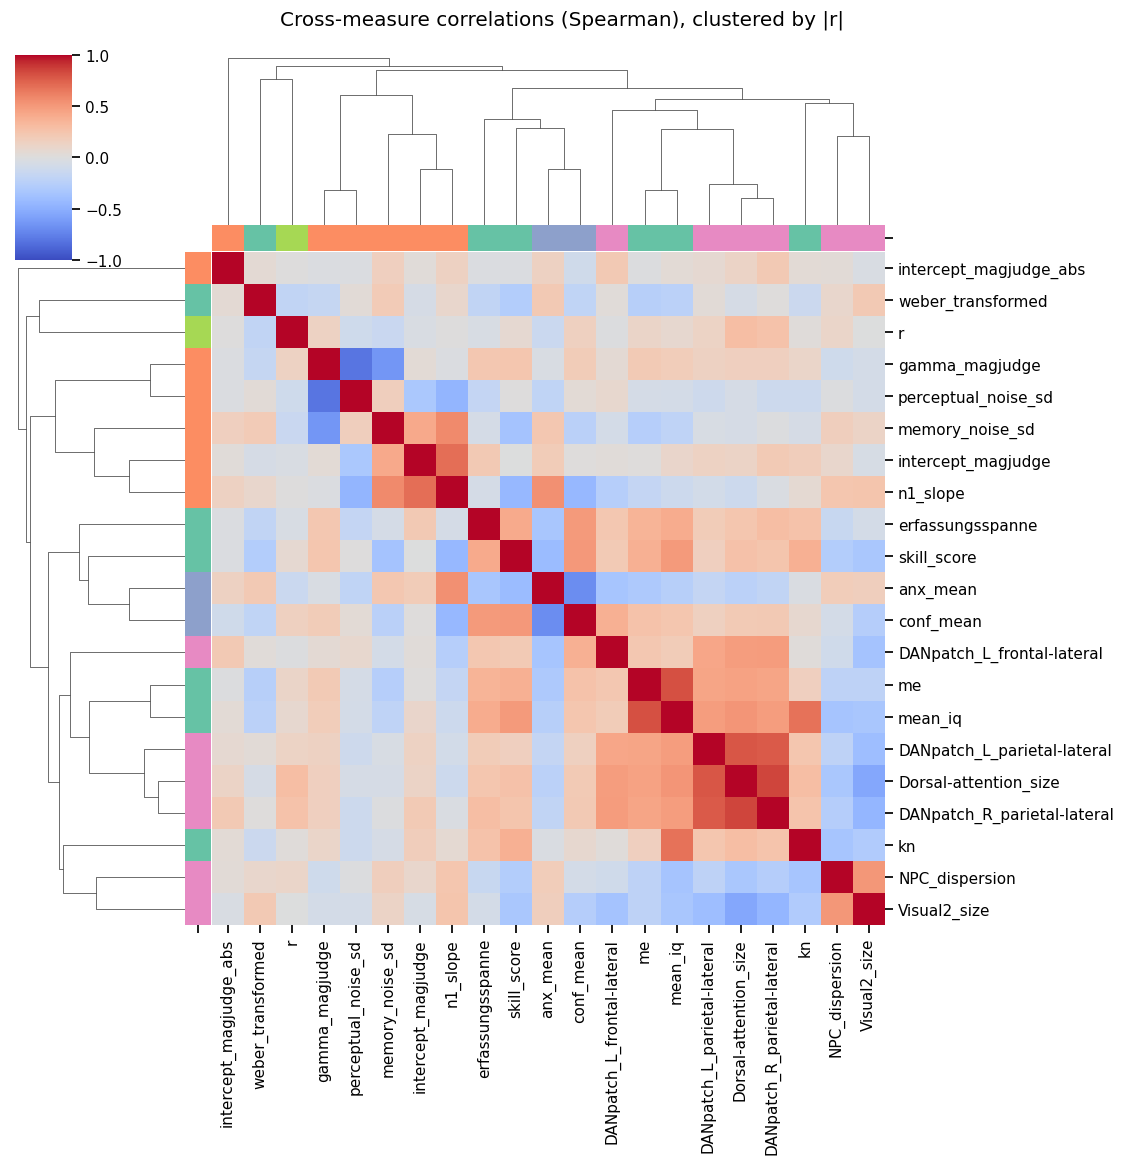

In [5]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

# 'signed': cluster on raw correlation values (default sns.clustermap behavior)
# 'abs':    cluster on correlation *strength* (1 - |r|) — groups variables that
#           move together strongly, regardless of whether they're positively or
#           negatively related.
cluster_on = 'abs'  # 'signed' or 'abs'

row_colors = pd.Series([palette[col_to_category[c]] for c in corr_vars], index=corr_vars)

if cluster_on == 'abs':
    dist = 1 - corr.abs()
    condensed = squareform(dist.values, checks=False)
    link = linkage(condensed, method='average')
    linkage_kwargs = dict(row_linkage=link, col_linkage=link)
    title_suffix = 'clustered by |r|'
else:
    linkage_kwargs = {}
    title_suffix = 'hierarchically clustered'

g = sns.clustermap(corr, cmap='coolwarm', vmin=-1, vmax=1,
                    row_colors=row_colors, col_colors=row_colors,
                    figsize=(0.4 * len(corr_vars) + 3, 0.4 * len(corr_vars) + 3),
                    **linkage_kwargs)
g.fig.suptitle(f'Cross-measure correlations (Spearman), {title_suffix}', y=1.02)
# g.savefig(op.join(plot_folder, 'cross_measure_clustermap.png'), dpi=300, bbox_inches='tight')

## Significant pairs (uncorrected) — quick scan

Long-format table of all pairwise correlations with p-values, sorted by
strength. Use this to spot candidates before drilling into a scatter plot.

In [6]:
import itertools

rows = []
for x_var, y_var in itertools.combinations(corr_vars, 2):
    sub = df[[x_var, y_var]].dropna()
    if len(sub) < 10:
        continue
    cor = pingouin.corr(sub[x_var], sub[y_var], method='spearman')
    rows.append({'x': x_var, 'y': y_var, 'r': cor['r'].iloc[0], 'p': cor['p-val'].iloc[0], 'n': cor['n'].iloc[0]})

pairs = pd.DataFrame(rows).sort_values('p')
pairs.head(20)

,x,y,r,p,n
203,Dorsal-attention_size,DANpatch_R_parietal-lateral,0.850219,3.257953e-19,65
145,me,mean_iq,0.808977,2.081671e-16,66
4,gamma_magjudge,perceptual_noise_sd,-0.806659,2.947149e-16,66
202,Dorsal-attention_size,DANpatch_L_parietal-lateral,0.781687,1.533027e-14,65
209,DANpatch_L_parietal-lateral,DANpatch_R_parietal-lateral,0.769231,7.166504e-14,65
119,anx_mean,conf_mean,-0.690817,1.370392e-10,66
20,intercept_magjudge,n1_slope,0.688968,1.605474e-10,66
155,kn,mean_iq,0.679343,3.592886e-10,66
3,gamma_magjudge,memory_noise_sd,-0.642584,6.008322e-09,66
40,n1_slope,memory_noise_sd,0.578123,3.709480e-07,66


## Variance explained with group effect removed

Partial-correlation matrix, controlling for `group` (control vs. dyscalc) —
shows how much two variables explain of each other's variance *beyond* what's
attributable to the group difference. Plotted as r² (variance explained, 0–1,
unsigned) rather than signed r, since "how much" is the question here.

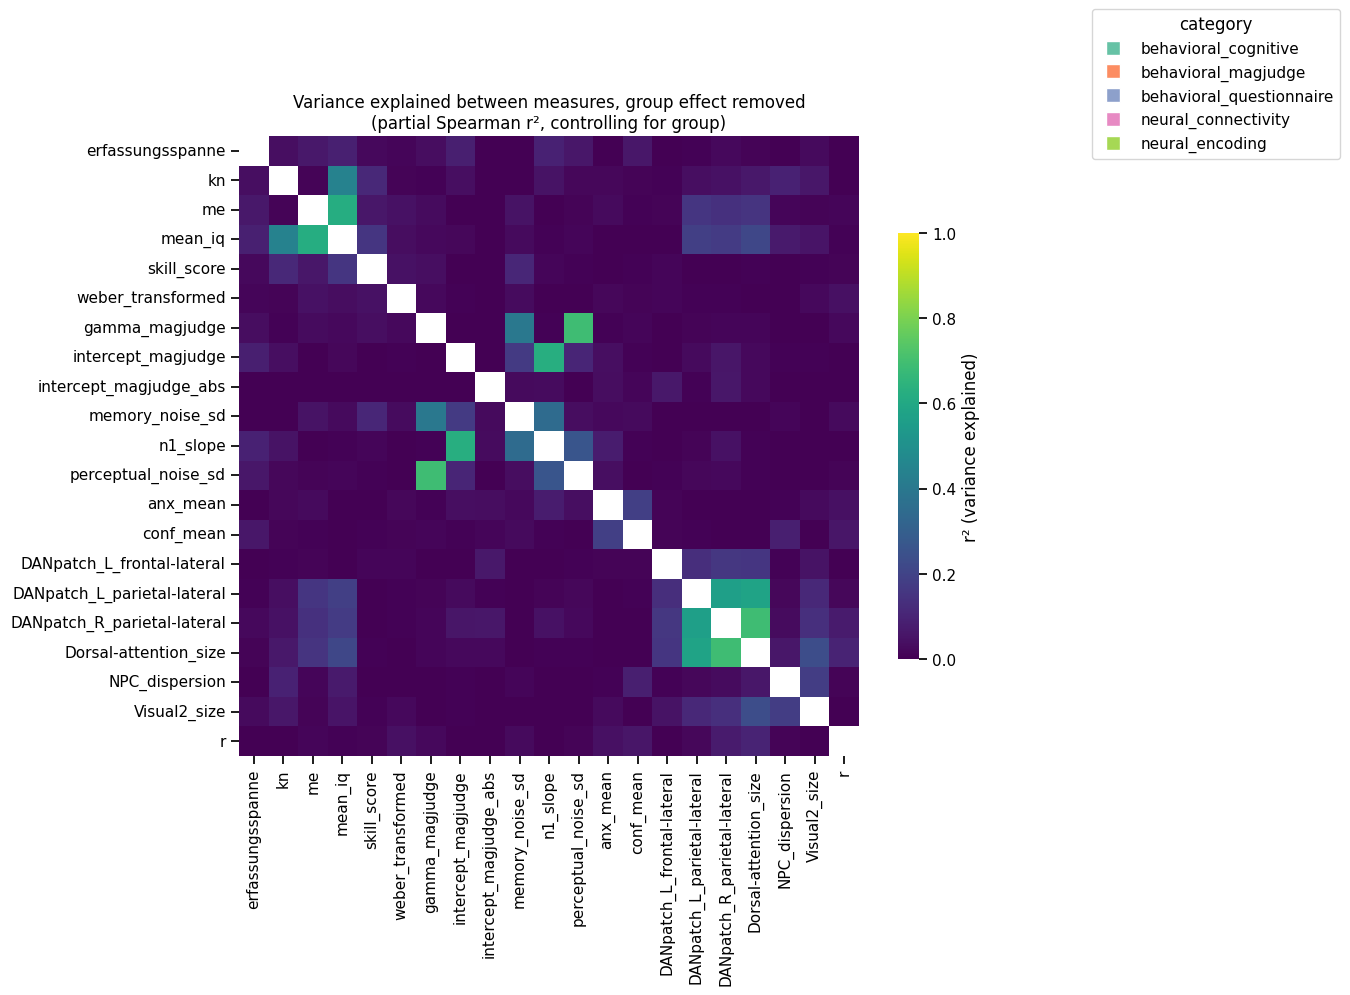

In [7]:
df_partial = df[corr_vars + ['group']].copy()
df_partial['group_numeric'] = (df_partial['group'] == 'dyscalc').astype(int)

partial_r = pd.DataFrame(np.eye(len(corr_vars)), index=corr_vars, columns=corr_vars)

for x_var, y_var in itertools.combinations(corr_vars, 2):
    sub = df_partial[[x_var, y_var, 'group_numeric']].dropna()
    if len(sub) < 10:
        continue
    res = pingouin.partial_corr(data=sub, x=x_var, y=y_var, covar='group_numeric', method='spearman')
    r = res['r'].iloc[0]
    partial_r.loc[x_var, y_var] = partial_r.loc[y_var, x_var] = r

partial_r2 = partial_r ** 2
np.fill_diagonal(partial_r2.values, np.nan)

partial_r2_sorted = partial_r2.loc[order, order]

fig, ax = plt.subplots(figsize=(0.4 * len(order) + 2, 0.4 * len(order) + 2))
sns.heatmap(partial_r2_sorted, cmap='viridis', vmin=0, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.5, 'label': 'r² (variance explained)'})
ax.set_title('Variance explained between measures, group effect removed\n(partial Spearman r², controlling for group)')

handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=palette[cat], markersize=10)
           for cat in categories]
fig.legend(handles, categories, loc='upper left', bbox_to_anchor=(1.05, 1), title='category')
plt.tight_layout()
# plt.savefig(op.join(plot_folder, 'cross_measure_partial_r2_group-removed.png'), dpi=300, bbox_inches='tight')

## Including risk-task measures

Pass `exclude_categories=set()` (or `include_categories=[..., 'behavioral_risk']`)
to bring risk-task measures into the same overview.

In [8]:
df_with_risk, col_to_category_with_risk = load_all(exclude_categories=set())
df_with_risk.shape

(66, 31)

## Group-split scatter for a chosen pair

Drop in any two column names from `corr_vars` above.

In [13]:
df.columns

Index(['age', 'group', 'gender', 'gamma_magjudge', 'intercept_magjudge',
       'n1_slope', 'intercept_magjudge_abs', 'memory_noise_sd',
       'perceptual_noise_sd', 'skill_score', 'anx_mean', 'conf_mean', 'me',
       'kn', 'mean_iq', 'erfassungsspanne', 'weber_transformed', 'r',
       'NPC_dispersion', 'Dorsal-attention_size', 'Visual2_size',
       'DANpatch_L_frontal-lateral', 'DANpatch_L_parietal-lateral',
       'DANpatch_R_parietal-lateral'],
      dtype='object')

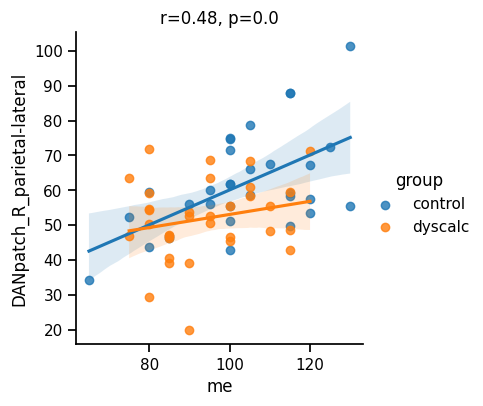

In [18]:
x_var = 'me'
y_var = 'DANpatch_R_parietal-lateral' # 'Dorsal-attention_size' # 

plot_df = df[[x_var, y_var, 'group']].dropna()
cor = pingouin.corr(plot_df[x_var], plot_df[y_var], method='pearson')  # 'spearman' or 'shepard'
r_, p_ = np.round(cor['r'].iloc[0], 2), np.round(cor['p-val'].iloc[0], 3)

fig = sns.lmplot(x=x_var, y=y_var, data=plot_df, hue='group', height=4)
fig.set(title=f'r={r_}, p={p_}')